In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('weather_data.csv')
print(df.head())

             Timestamp  Temperature  Humidity  Wet_Bulb
0  2026-04-29 22:59:24         25.9      78.0     22.91
1  2026-04-29 23:00:20         25.8      79.0     22.96
2  2026-04-29 23:01:22         26.2      78.0     23.20
3  2026-04-29 23:25:14         26.5      75.0     23.06
4  2026-04-29 23:26:16         26.6      76.0     23.30


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    1987 non-null   str    
 1   Temperature  1987 non-null   float64
 2   Humidity     1987 non-null   float64
 3   Wet_Bulb     1987 non-null   float64
dtypes: float64(3), str(1)
memory usage: 62.2 KB


In [4]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    1987 non-null   datetime64[us]
 1   Temperature  1987 non-null   float64       
 2   Humidity     1987 non-null   float64       
 3   Wet_Bulb     1987 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 62.2 KB


In [6]:
# df = df.drop_duplicates(subset=['Timestamp'])

In [7]:
# print(df.info())

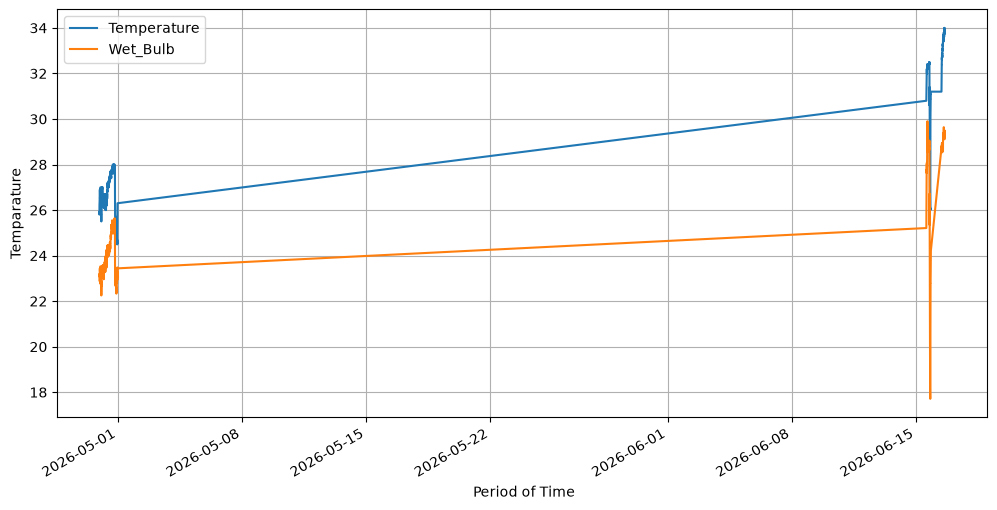

In [8]:
df.set_index('Timestamp', inplace=True)
df[["Temperature", "Wet_Bulb"]].plot(figsize = (12, 6))
plt.xlabel(" Period of Time")
plt.ylabel("Temparature")
# plt.savefig("Graph Temp vs Period of Time of both room temp and wet bulb", dpi=300)
plt.grid(True)
plt.show()

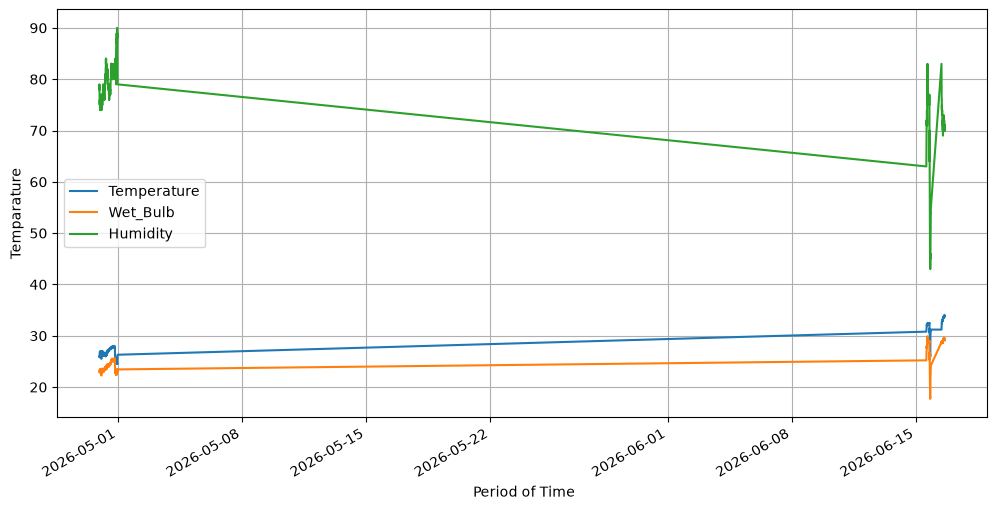

In [9]:
df[["Temperature", "Wet_Bulb", "Humidity"]].plot(figsize = (12, 6))
plt.xlabel(" Period of Time")
plt.ylabel("Temparature")
# plt.savefig("Graph Temp vs Period of Time of both room temp, humidity and wet bulb", dpi=300)
plt.grid(True)
plt.show()

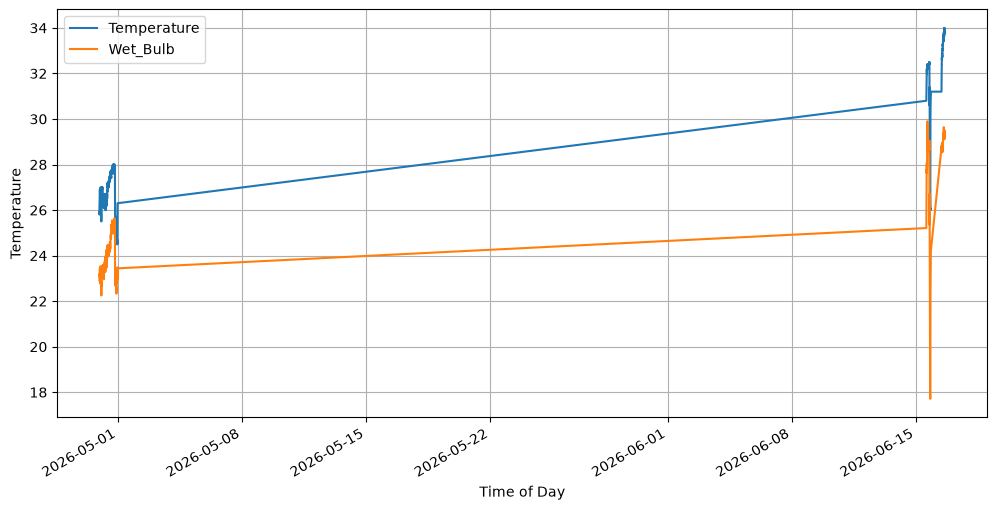

In [10]:
# 1. Set the index first (inplace=True makes sure it saves to the 'df' variable)
# df.set_index('Timestamp', inplace=True)

# 2. Now plot. Pandas will see the index is a 'datetime' and use it for the X-axis
df[["Temperature", "Wet_Bulb"]].plot(figsize=(12, 6))

# 3. Standard formatting
plt.xlabel("Time of Day") # Updated label to reflect actual time
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

In [11]:
print(df.head(),"\n\n")
df.info()

                     Temperature  Humidity  Wet_Bulb
Timestamp                                           
2026-04-29 22:59:24         25.9      78.0     22.91
2026-04-29 23:00:20         25.8      79.0     22.96
2026-04-29 23:01:22         26.2      78.0     23.20
2026-04-29 23:25:14         26.5      75.0     23.06
2026-04-29 23:26:16         26.6      76.0     23.30 


<class 'pandas.DataFrame'>
DatetimeIndex: 1987 entries, 2026-04-29 22:59:24 to 2026-06-16 15:08:38
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  1987 non-null   float64
 1   Humidity     1987 non-null   float64
 2   Wet_Bulb     1987 non-null   float64
dtypes: float64(3)
memory usage: 62.1 KB


In [12]:
df_resampled = df.resample('5min').mean()
df_resampled.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 13731 entries, 2026-04-29 22:55:00 to 2026-06-16 15:05:00
Freq: 5min
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  417 non-null    float64
 1   Humidity     417 non-null    float64
 2   Wet_Bulb     417 non-null    float64
dtypes: float64(3)
memory usage: 429.1 KB


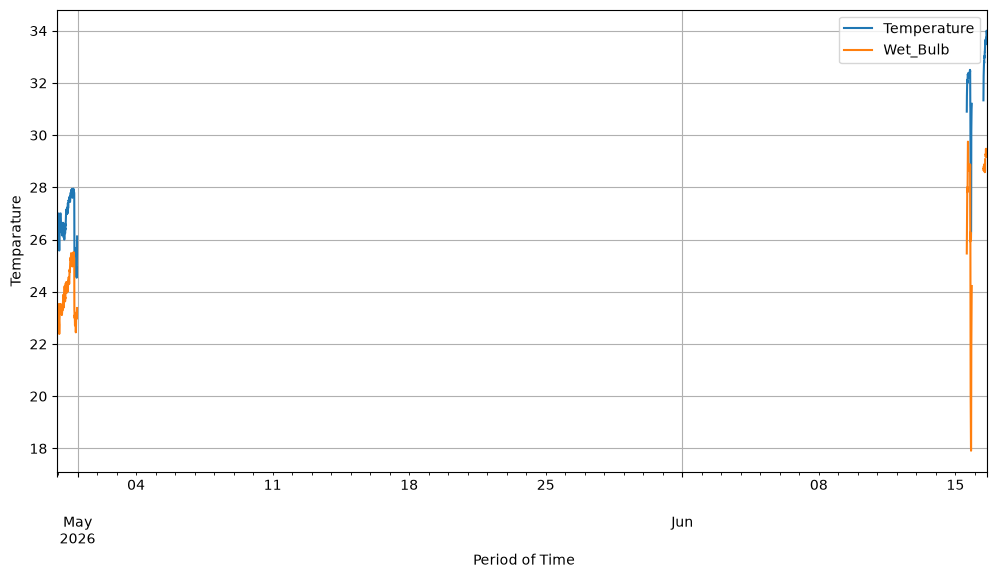

In [13]:
# df.set_index('Timestamp', inplace=True)
df_resampled[["Temperature", "Wet_Bulb"]].plot(figsize = (12, 6))
plt.xlabel(" Period of Time")
plt.ylabel("Temparature")
# plt.savefig("Graph Temp vs Period of Time of both room temp and wet bulb", dpi=300)
plt.grid(True)
plt.show()

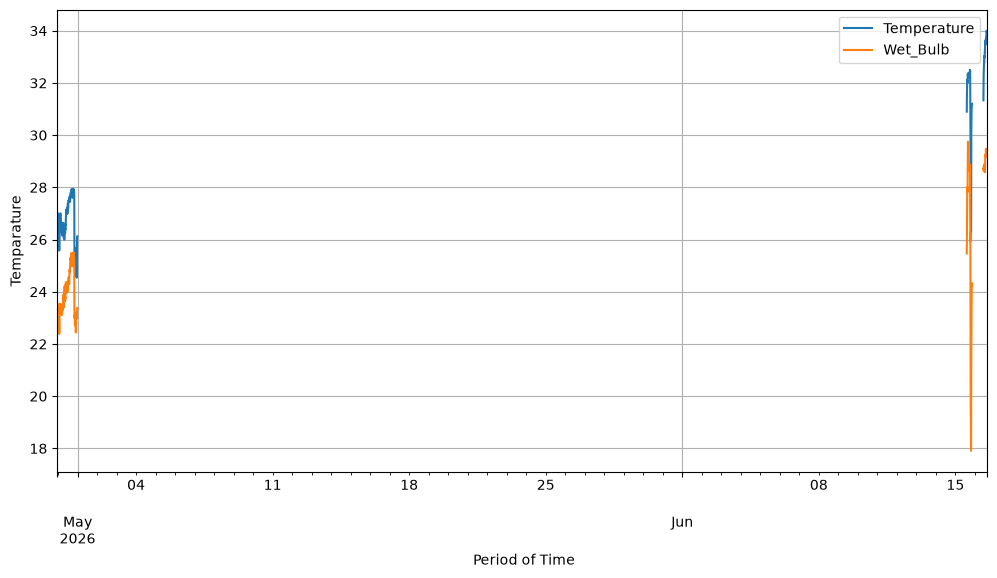

In [14]:
df_resampled = df_resampled.interpolate(method='time', limit=4)
# df.set_index('Timestamp', inplace=True)

df_resampled[["Temperature", "Wet_Bulb"]].plot(figsize = (12, 6))
plt.xlabel(" Period of Time")
plt.ylabel("Temparature")
# plt.savefig("Graph Temp vs Period of Time of both room temp and wet bulb", dpi=300)
plt.grid(True)
plt.show()

In [15]:
df_resampled['WB_rolling_15min'] = df_resampled['Wet_Bulb'].rolling(3).mean()
df_resampled.info()
print("\n\n",df_resampled.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 13731 entries, 2026-04-29 22:55:00 to 2026-06-16 15:05:00
Freq: 5min
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature       434 non-null    float64
 1   Humidity          434 non-null    float64
 2   Wet_Bulb          434 non-null    float64
 3   WB_rolling_15min  428 non-null    float64
dtypes: float64(4)
memory usage: 536.4 KB


                      Temperature  Humidity  Wet_Bulb  WB_rolling_15min
Timestamp                                                             
2026-04-29 22:55:00       25.900     78.00    22.910               NaN
2026-04-29 23:00:00       26.000     78.50    23.080               NaN
2026-04-29 23:05:00       26.128     77.88    23.114         23.034667
2026-04-29 23:10:00       26.256     77.26    23.148         23.114000
2026-04-29 23:15:00       26.384     76.64    23.182         23.148000


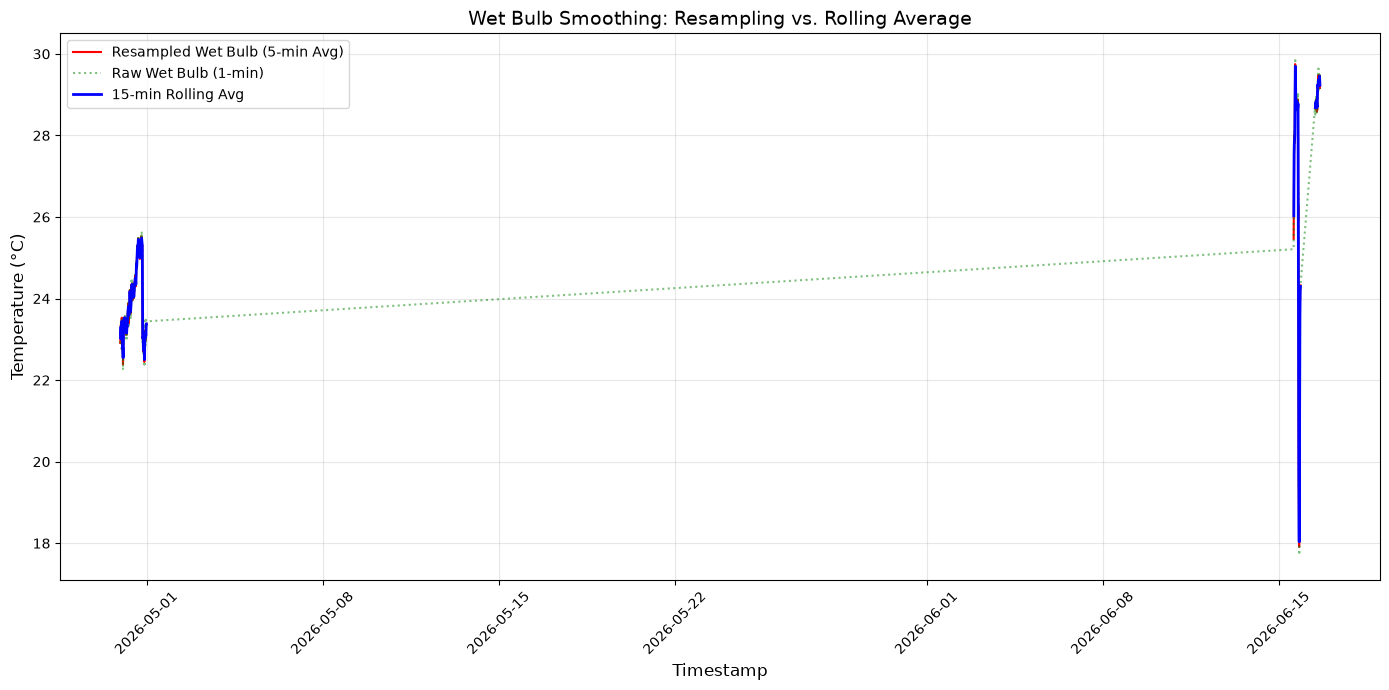

In [16]:
plt.figure(figsize=(14, 7))
plt.plot(df_resampled.index, df_resampled['Wet_Bulb'], label='Resampled Wet Bulb (5-min Avg)', color='red', linewidth=1.5)
plt.plot(df.index, df['Wet_Bulb'], label='Raw Wet Bulb (1-min)', color='green', alpha=0.5, linestyle=':')
plt.plot(df_resampled.index, df_resampled['WB_rolling_15min'], label='15-min Rolling Avg', color='blue', linewidth=2)

plt.title('Wet Bulb Smoothing: Resampling vs. Rolling Average', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

# plt.savefig('resampled_rolling_analysis.png')
plt.show()

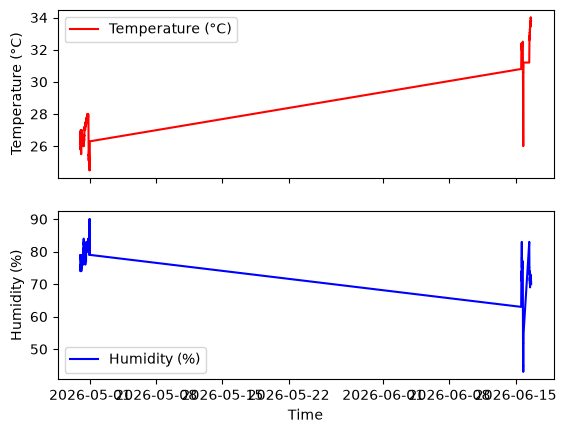

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(df.index, df['Temperature'], 'r-', label='Temperature (°C)')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()

ax2.plot(df.index, df['Humidity'], 'b-', label='Humidity (%)')
ax2.set_ylabel('Humidity (%)')
ax2.set_xlabel('Time')
ax2.legend()

plt.show()

### Nurmalising the data

In [18]:
from sklearn.preprocessing import StandardScaler

features = ['Temperature', 'Humidity', 'Wet_Bulb']
x = df[features]
scaler = StandardScaler()
data_norm = scaler.fit_transform(x)

print(data_norm)

[[-0.90250467  0.18483414 -0.87018429]
 [-0.93899863  0.31819123 -0.84967787]
 [-0.79302279  0.18483414 -0.75124705]
 ...
 [ 1.9805183  -0.88202259  1.68491558]
 [ 1.9805183  -0.88202259  1.68491558]
 [ 1.9805183  -0.88202259  1.68491558]]


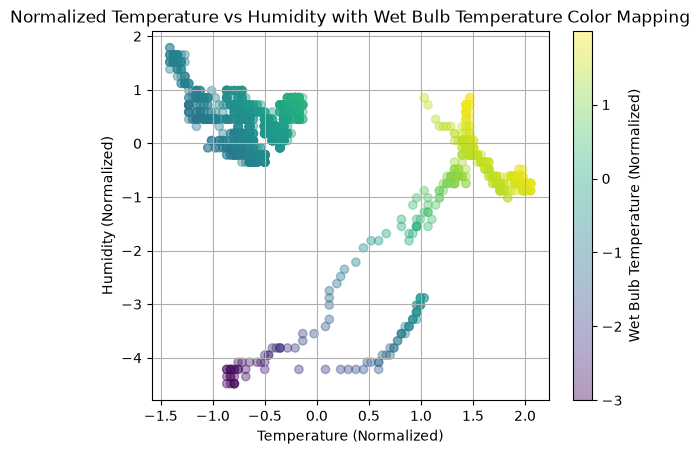

In [19]:
plt.scatter(data_norm[:, 0], data_norm[:, 1], c=data_norm[:, 2], cmap='viridis', alpha=0.4)
plt.colorbar(label='Wet Bulb Temperature (Normalized)')
plt.xlabel('Temperature (Normalized)')
plt.ylabel('Humidity (Normalized)')
plt.title('Normalized Temperature vs Humidity with Wet Bulb Temperature Color Mapping')
plt.grid(True)
plt.show()

In [20]:
from sklearn.cluster import KMeans

wcss = []
# Test K values from 1 to 10
for i in range(1, 11):
    # 'init=k-means++' places initial centroids smartly to speed up convergence
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    # .inertia_ gives us the calculated WCSS value
    wcss.append(kmeans.inertia_)

In [21]:
# Initialize and fit the final model
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

# fit_predict assigns a cluster label (0, 1, or 2) to each row
df['Cluster'] = kmeans.fit_predict(x)

In [22]:
# Grouping by cluster and taking the average reveals what each group represents
cluster_profiles = df.groupby('Cluster')[features].mean()
print(cluster_profiles)

         Temperature   Humidity   Wet_Bulb
Cluster                                   
0          32.719262  73.135246  28.637664
1          28.702128  48.776596  20.982340
2          26.841423  79.684698  24.050206


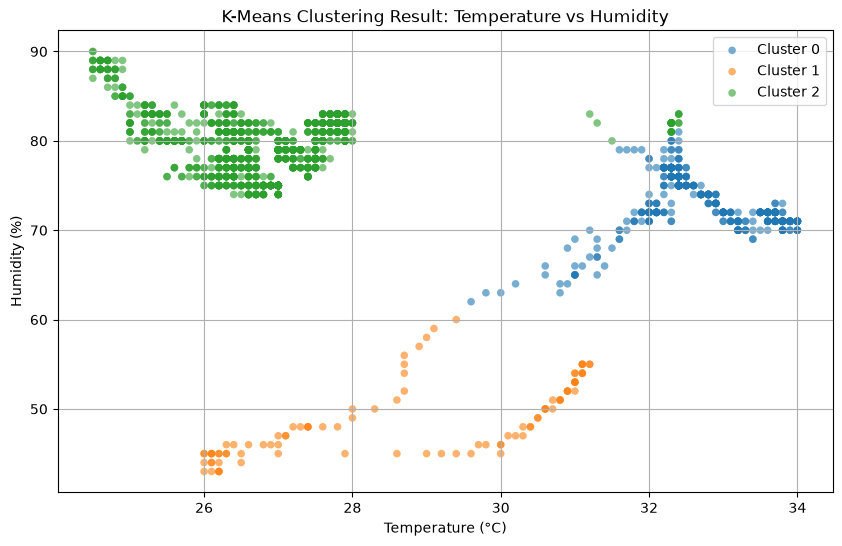

--- Cluster Profiles (Mean Values) ---
         Temperature   Humidity   Wet_Bulb
Cluster                                   
0          32.719262  73.135246  28.637664
1          28.702128  48.776596  20.982340
2          26.841423  79.684698  24.050206

--- Samples per Cluster ---
Cluster
2    1405
0     488
1      94
Name: count, dtype: int64


In [ ]:
# Save the clustered dataset back to disk
df.to_csv('weather_data_with_clusters.csv', index=False)

# 5. Visualize the Clusters (Temperature vs Humidity)
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71'] # Custom clear colors
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Temperature'], cluster_data['Humidity'], 
                label=f'Cluster {cluster}', alpha=0.6, edgecolors='none', s=30)
plt.title('K-Means Clustering Result: Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.legend()
plt.grid(True)
# plt.savefig('kmeans_temp_vs_humidity.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Print the profiles of each cluster
print("--- Cluster Profiles (Mean Values) ---")
cluster_profiles = df.groupby('Cluster')[features].mean()
print(cluster_profiles)
print("\n--- Samples per Cluster ---")
print(df['Cluster'].value_counts())